In [2]:
# setting up stuff
using QuantumOptics
using LinearAlgebra

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)
;

In [3]:
function twoLevelSysFromParameters(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H)
    return tout, psi_t, t->H(t, nothing)
end

function rydberg_blockaded_system(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    H_01(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 
    H_11(t, ignored) = sqrt(2)*Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi01_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_01)
    _,    psi11_t = timeevolution.schroedinger_dynamic(tspan, Ψ₀, H_11)
    return tout, (psi01_t, t->H_01(t, nothing)), (psi11_t, t->H_11(t, nothing))
end

rydberg_blockaded_system (generic function with 1 method)

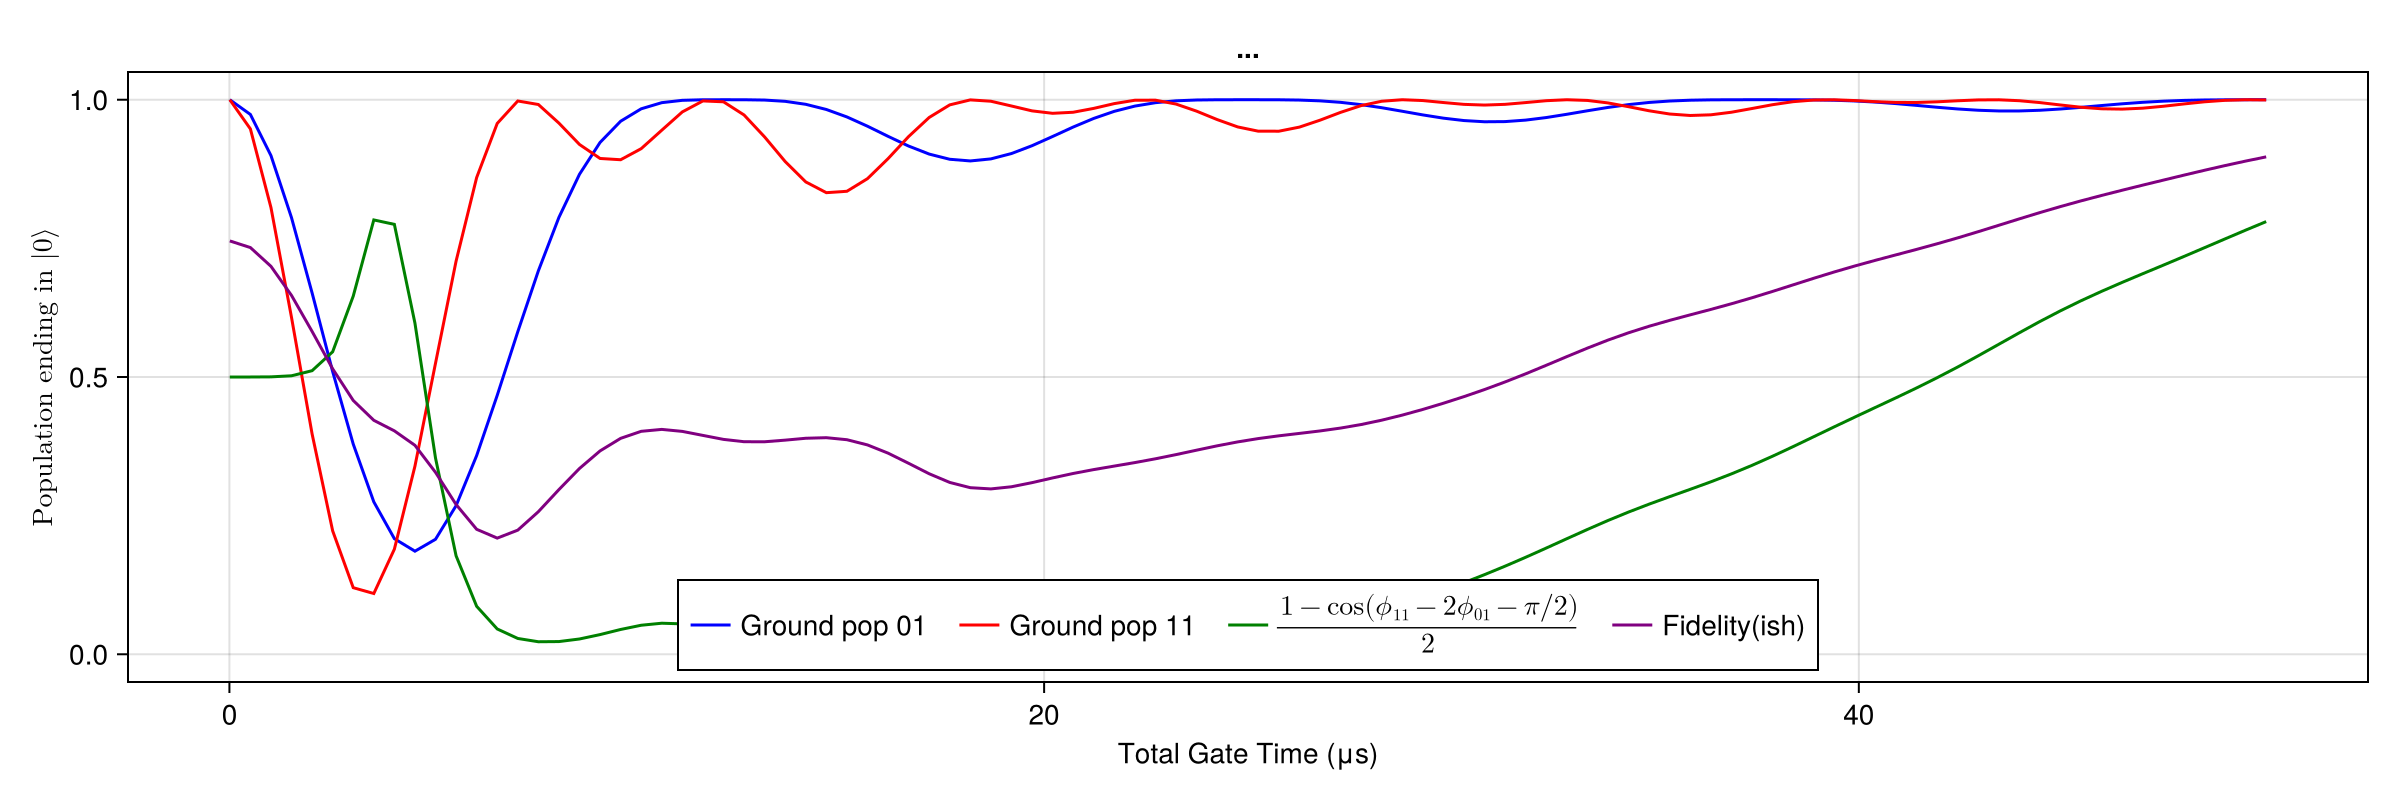

CairoMakie.Screen{IMAGE}


In [10]:
using Interpolations
using QuantumOptics
using CairoMakie

function const_thetadot(T::Real, Ω_max=1)

    Δ(t) = -abs(cos(π*t/(T))) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    Ω(t) = Ω_max*sin(π*t/(T))
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end


iterations = 100
tmin = 0.01
tmax = 50
Ts = range(tmin, tmax, iterations)

# 01 bloch sphere
gate_01_results = const_thetadot.(Ts, 1)
psi_t = getindex.(getindex.(gate_01_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_01 = abs2.(down_end_amplitude)
zero_inner_01 = abs.(down_end_amplitude)
ϕ_01 = angle.(down_end_amplitude)

# 11 bloch sphere
gate_11_results = const_thetadot.(Ts, sqrt(2))
psi_t = getindex.(getindex.(gate_11_results,1), 2)
psi_end = getindex.(psi_t, length(psi_t[1]))
down_end_amplitude = getindex.(psi_end, 2)
ending_population_11 = abs2.(down_end_amplitude)
zero_inner_11 = abs.(down_end_amplitude)
ϕ_11 = angle.(down_end_amplitude)

phase_accum = ϕ_11 .- 2 .* ϕ_01
cos_phase_accum = (1 .+ cos.(phase_accum .- π/2)) ./ 2
fidelity = abs.((2 .* zero_inner_01 .+ cis.(phase_accum .- π/2 ) .* zero_inner_11) ./ 3)


# plotting
fig = Figure(size=(1200, 400))
ax1 = Axis(fig[1, 1], yticklabelcolor = :black,
    title = "...",
    xlabel = "Total Gate Time (μs)",
    ylabel = L"Population ending in $|0\rangle$",
    # xticks = (0:0.5:tmax)
)

lines!(ax1, Ts, ending_population_01, color = :blue, label = "Ground pop 01")
lines!(ax1, Ts, ending_population_11, color = :red, label = "Ground pop 11")
lines!(ax1, Ts, cos_phase_accum, color = :green, label = L"\frac{1-\cos(\phi_{11} - 2\phi_{01} - \pi/2)}{2}")
lines!(ax1, Ts, fidelity, color = :purple, label = "Fidelity(ish)")

axislegend(ax1, position = :cb, orientation = :horizontal)

display(fig)